Sales Plan Analysis

1. Data Wrangling

In [40]:
import pandas as pd

df = pd.read_csv('/content/AusApparalSales4thQrt2020.csv')

df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [41]:
#to find any missing values
missing = df.isna()
step = 0

for x in missing.values.flatten():
  if x:
    step += 1

print(step)

0


In [42]:
#to find existing values
existing = df.notna()
step = 0

for x in existing.values.flatten():
  if x:
    step += 1

print(step)

45360


Since there are no missing values/ incorrect data there is no need to drop/fill any cell

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize the 'Sales' column
df['Normalized_Sales'] = scaler.fit_transform(df[['Sales']])

# Display the DataFrame with normalized sales
print(df)

             Date        Time State     Group  Unit  Sales  Normalized_Sales
0      1-Oct-2020     Morning    WA      Kids     8  20000          0.095238
1      1-Oct-2020     Morning    WA       Men     8  20000          0.095238
2      1-Oct-2020     Morning    WA     Women     4  10000          0.031746
3      1-Oct-2020     Morning    WA   Seniors    15  37500          0.206349
4      1-Oct-2020   Afternoon    WA      Kids     3   7500          0.015873
...           ...         ...   ...       ...   ...    ...               ...
7555  30-Dec-2020   Afternoon   TAS   Seniors    14  35000          0.190476
7556  30-Dec-2020     Evening   TAS      Kids    15  37500          0.206349
7557  30-Dec-2020     Evening   TAS       Men    15  37500          0.206349
7558  30-Dec-2020     Evening   TAS     Women    11  27500          0.142857
7559  30-Dec-2020     Evening   TAS   Seniors    13  32500          0.174603

[7560 rows x 7 columns]


The GroupBy() function in pandas is a powerful tool for data analysis, enabling you to aggregate, transform, or filter data efficiently. Here are some insights regarding its applications for data chunking and merging:

Insights on GroupBy():
Data Aggregation:

The primary use of GroupBy() is to aggregate data based on one or more keys. This allows you to compute summary statistics (like mean, sum, count) for different groups, which is essential for understanding distributions and trends within your data.

Data Chunking:
By grouping data, you can effectively "chunk" it into smaller, manageable pieces. This is particularly useful for large datasets, where analyzing the whole dataset at once may be impractical due to memory constraints.

Transformation and Filtering:
GroupBy() can also be used for transforming data by applying functions to each group. You can filter groups based on specific criteria, allowing for focused analysis on subsets of your data.
Merging Data:

While GroupBy() itself does not merge data, it can work alongside merging processes. For example, after aggregating data with GroupBy(), you can merge the results back into the original DataFrame for further analysis or visualization.

2. Data Analysis

In [44]:
#Descriptive stats
from scipy import stats

sales_stats = df['Sales'].describe()
sales_median =df['Sales'].median()
#sales_mode = stats.mode(df['Sales'])[0][0]
sales_mode =df['Sales'].mode()
unit_stats= df['Unit'].describe()
unit_median= df['Unit'].median()
unit_mode= df['Unit'].mode()

print("Sales stats:")
print(sales_stats)
print("Sales median:", sales_median)
print("Sales mode:", sales_mode)
print("Unit stats:")
print(unit_stats)
print("Unit median:", unit_median)
print("Unit mode:", unit_mode)

Sales stats:
count      7560.000000
mean      45013.558201
std       32253.506944
min        5000.000000
25%       20000.000000
50%       35000.000000
75%       65000.000000
max      162500.000000
Name: Sales, dtype: float64
Sales median: 35000.0
Sales mode: 0    22500
Name: Sales, dtype: int64
Unit stats:
count    7560.000000
mean       18.005423
std        12.901403
min         2.000000
25%         8.000000
50%        14.000000
75%        26.000000
max        65.000000
Name: Unit, dtype: float64
Unit median: 14.0
Unit mode: 0    9
Name: Unit, dtype: int64


Descriptive Statistics for Sales:
Mean: 45013.5582010582, Median: 35000.0, Mode: 0    22500
Name: Sales, dtype: int64, Standard Deviation: 32253.506943966317

Descriptive Statistics for Unit:
Mean: 18.00542328042328, Median: 14.0, Mode: 0    9
Name: Unit, dtype: int64, Standard Deviation: 12.901402777586458


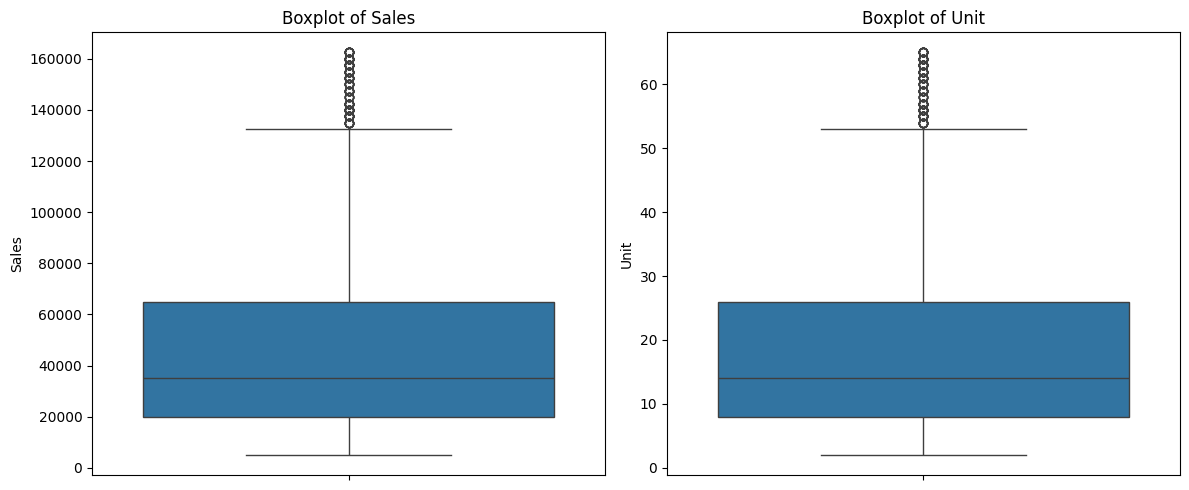

In [45]:
import seaborn as sns
from scipy import stats

sales_mean = df['Sales'].mean()
sales_std = df['Sales'].std()

# Descriptive statistics for Unit
unit_mean = df['Unit'].mean()
unit_std = df['Unit'].std()

# Display the results
print("Descriptive Statistics for Sales:")
print(f"Mean: {sales_mean}, Median: {sales_median}, Mode: {sales_mode}, Standard Deviation: {sales_std}")

print("\nDescriptive Statistics for Unit:")
print(f"Mean: {unit_mean}, Median: {unit_median}, Mode: {unit_mode}, Standard Deviation: {unit_std}")

# Plotting boxplots for Sales and Unit
plt.figure(figsize=(12, 5))

# Boxplot for Sales
plt.subplot(1, 2, 1)
sns.boxplot(y='Sales', data=df)
plt.title('Boxplot of Sales')
plt.ylabel('Sales')

# Boxplot for Unit
plt.subplot(1, 2, 2)
sns.boxplot(y='Unit', data=df)
plt.title('Boxplot of Unit')
plt.ylabel('Unit')

plt.tight_layout()
plt.show()

In [46]:
#group with the highest sales and the group with the lowest sales based on the data provided.
grouped_sales = df.groupby('Group')['Sales'].sum()

# Identify the group with the highest and lowest sales
highest_sales_group = grouped_sales.idxmax()
highest_sales_value = grouped_sales.max()

lowest_sales_group = grouped_sales.idxmin()
lowest_sales_value = grouped_sales.min()

# Display the results
print(f"Group with the highest sales: {highest_sales_group} with sales of {highest_sales_value}")
print(f"Group with the lowest sales: {lowest_sales_group} with sales of {lowest_sales_value}")

Group with the highest sales:  Men with sales of 85750000
Group with the lowest sales:  Seniors with sales of 84037500


In [47]:
df['Date'] = pd.to_datetime(df['Date'])

# Set the date as the index
df.set_index('Date', inplace=True)

# Weekly Report
weekly_report = df.resample('W').sum()
weekly_mean = weekly_report['Sales'].mean()
weekly_std = weekly_report['Sales'].std()

# Monthly Report
monthly_report = df.resample('M').sum()
monthly_mean = monthly_report['Sales'].mean()
monthly_std = monthly_report['Sales'].std()

# Quarterly Report
quarterly_report = df.resample('Q').sum()
quarterly_mean = quarterly_report['Sales'].mean()
quarterly_std = quarterly_report['Sales'].std()

# Display the reports
print("Weekly Report:")
print(weekly_report)
print(f"Weekly Mean Sales: {weekly_mean}, Standard Deviation: {weekly_std}\n")

print("Monthly Report:")
print(monthly_report)
print(f"Monthly Mean Sales: {monthly_mean}, Standard Deviation: {monthly_std}\n")

print("Quarterly Report:")
print(quarterly_report)
print(f"Quarterly Mean Sales: {quarterly_mean}, Standard Deviation: {quarterly_std}\n")

Weekly Report:
                                                         Time  \
Date                                                            
2020-10-04   Morning Morning Morning Morning Afternoon Aft...   
2020-10-11   Morning Morning Morning Morning Afternoon Aft...   
2020-10-18   Morning Morning Morning Morning Afternoon Aft...   
2020-10-25   Morning Morning Morning Morning Afternoon Aft...   
2020-11-01   Morning Morning Morning Morning Afternoon Aft...   
2020-11-08   Morning Morning Morning Morning Afternoon Aft...   
2020-11-15   Morning Morning Morning Morning Afternoon Aft...   
2020-11-22   Morning Morning Morning Morning Afternoon Aft...   
2020-11-29   Morning Morning Morning Morning Afternoon Aft...   
2020-12-06   Morning Morning Morning Morning Afternoon Aft...   
2020-12-13   Morning Morning Morning Morning Afternoon Aft...   
2020-12-20   Morning Morning Morning Morning Afternoon Aft...   
2020-12-27   Morning Morning Morning Morning Afternoon Aft...   
2021-01-03

<ipython-input-47-76c291bfe66b>:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_report = df.resample('M').sum()
<ipython-input-47-76c291bfe66b>:17: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_report = df.resample('Q').sum()


3. Data visualisation

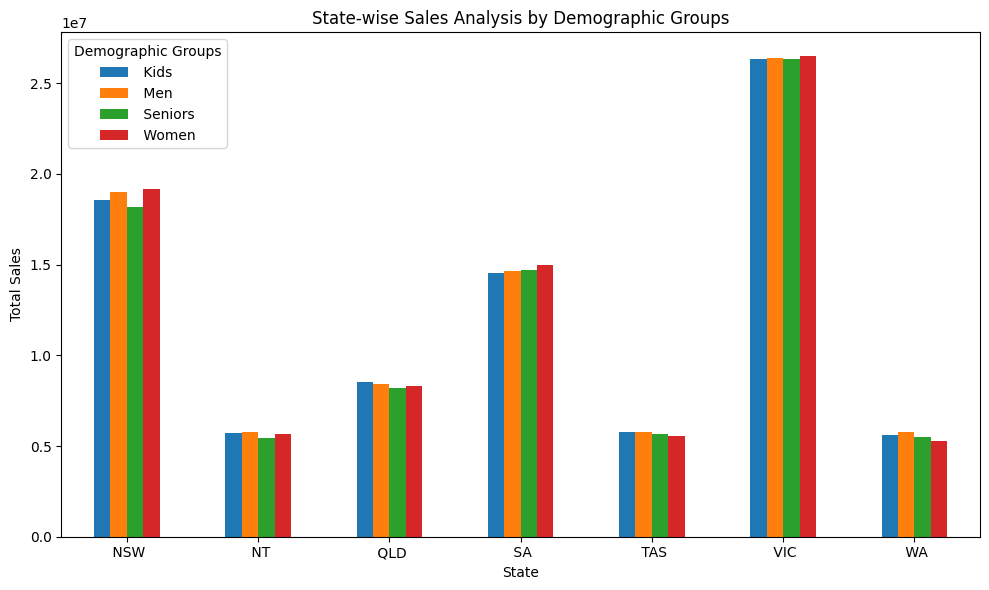

In [48]:
#State-wise sales analysis for different demographic groups (kids, women, men, and seniors).

import matplotlib.pyplot as plt
state_group_sales = df.groupby(['State', 'Group'])['Sales'].sum().unstack()

# Plotting
state_group_sales.plot(kind='bar', figsize=(10, 6))
plt.title('State-wise Sales Analysis by Demographic Groups')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Demographic Groups')
plt.tight_layout()
plt.show()

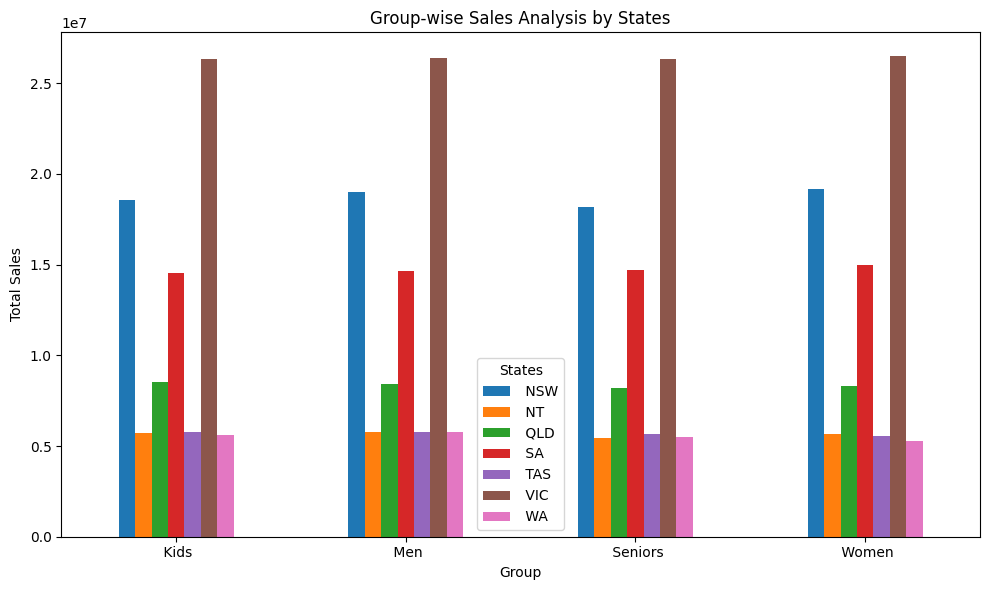

In [49]:
#Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states.

state_group_sales = df.groupby(['Group','State'])['Sales'].sum().unstack()

# Plotting
state_group_sales.plot(kind='bar', figsize=(10, 6))
plt.title('Group-wise Sales Analysis by States')
plt.xlabel('Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='States')
plt.tight_layout()
plt.show()

Sales by Time of Day:
         Time      Sales
0   Afternoon  114007500
1     Evening  112087500
2     Morning  114207500

Peak Sales Period:  Morning with Sales: 114207500
Off-Peak Sales Period:  Evening with Sales: 112087500


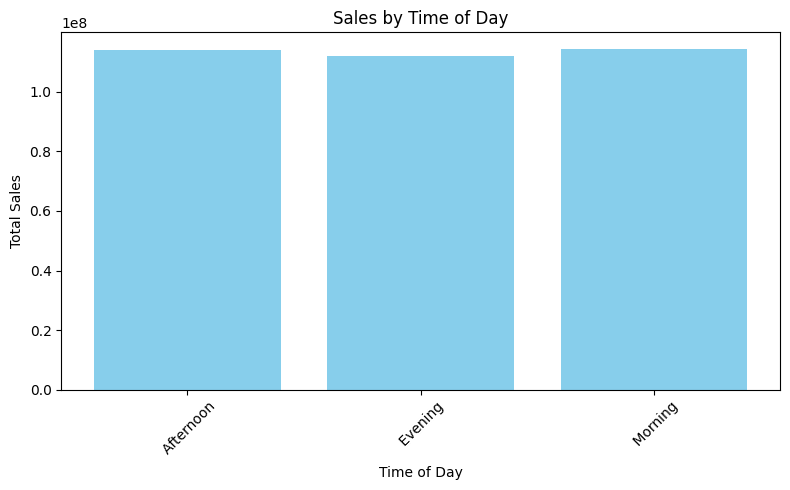

In [50]:
#Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams

# Group by Time and calculate total sales
time_sales = df.groupby('Time')['Sales'].sum().reset_index()

# Identify peak and off-peak periods
peak_time = time_sales.loc[time_sales['Sales'].idxmax()]
off_peak_time = time_sales.loc[time_sales['Sales'].idxmin()]

# Display results
print("Sales by Time of Day:")
print(time_sales)
print(f"\nPeak Sales Period: {peak_time['Time']} with Sales: {peak_time['Sales']}")
print(f"Off-Peak Sales Period: {off_peak_time['Time']} with Sales: {off_peak_time['Sales']}")

# Plotting sales by time of day
plt.figure(figsize=(8, 5))
plt.bar(time_sales['Time'], time_sales['Sales'], color='skyblue')
plt.title('Sales by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales by Day and Time of Day:
          Day        Time     Sales
0      Friday   Afternoon  16110000
1      Friday     Evening  15627500
2      Friday     Morning  16262500
3      Monday   Afternoon  16332500
4      Monday     Evening  15855000
5      Monday     Morning  15862500
6    Saturday   Afternoon  15085000
7    Saturday     Evening  15225000
8    Saturday     Morning  15935000
9      Sunday   Afternoon  16442500
10     Sunday     Evening  16022500
11     Sunday     Morning  15865000
12   Thursday   Afternoon  16405000
13   Thursday     Evening  16212500
14   Thursday     Morning  16787500
15    Tuesday   Afternoon  16870000
16    Tuesday     Evening  16577500
17    Tuesday     Morning  16880000
18  Wednesday   Afternoon  16762500
19  Wednesday     Evening  16567500
20  Wednesday     Morning  16615000

Peak Sales Period: Tuesday -  Morning with Sales: 16880000
Off-Peak Sales Period: Saturday -  Afternoon with Sales: 15085000


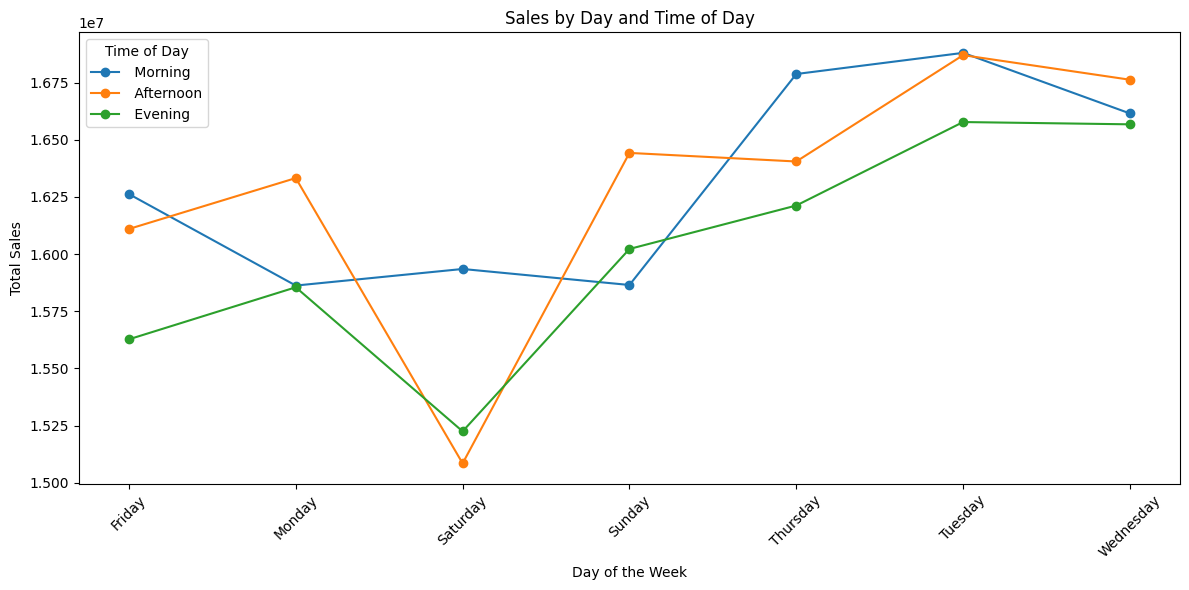

In [51]:
#Checking peak and off-peak sales period with day of the week

# Reset the index to make 'Date' a column again
df.reset_index(inplace=True)

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract the day of the week
df['Day'] = df['Date'].dt.day_name()

# Group by Day and Time, then calculate total sales
weekly_time_sales = df.groupby(['Day', 'Time'])['Sales'].sum().reset_index()

# Identify peak and off-peak periods for each day
peak_sales = weekly_time_sales.loc[weekly_time_sales['Sales'].idxmax()]
off_peak_sales = weekly_time_sales.loc[weekly_time_sales['Sales'].idxmin()]

# Display results
print("Sales by Day and Time of Day:")
print(weekly_time_sales)
print(f"\nPeak Sales Period: {peak_sales['Day']} - {peak_sales['Time']} with Sales: {peak_sales['Sales']}")
print(f"Off-Peak Sales Period: {off_peak_sales['Day']} - {off_peak_sales['Time']} with Sales: {off_peak_sales['Sales']}")

# Plotting sales by day and time of day
plt.figure(figsize=(12, 6))
for time in df['Time'].unique():
    subset = weekly_time_sales[weekly_time_sales['Time'] == time]
    plt.plot(subset['Day'], subset['Sales'], marker='o', label=time)

plt.title('Sales by Day and Time of Day')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Time of Day')
plt.tight_layout()
plt.show()

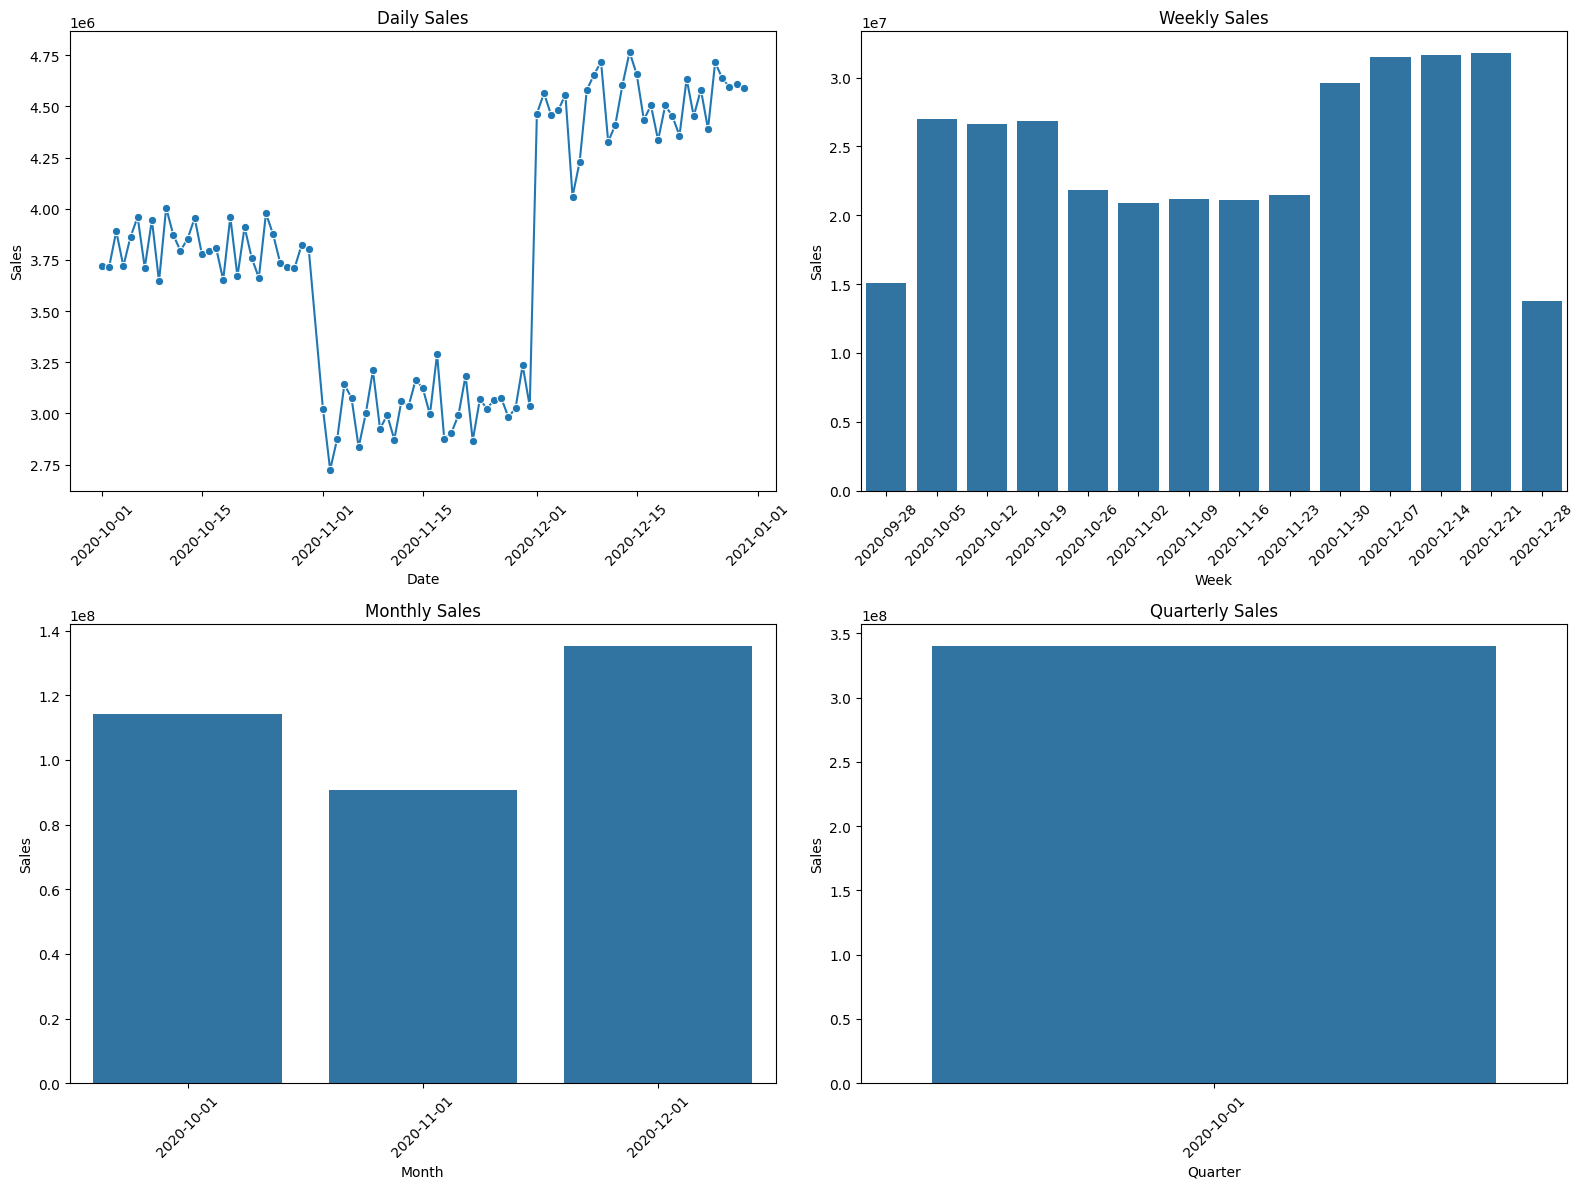

In [52]:

# Daily sales
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()

# Weekly sales
df['Week'] = df['Date'].dt.to_period('W').dt.start_time
weekly_sales = df.groupby('Week')['Sales'].sum().reset_index()

# Monthly sales
df['Month'] = df['Date'].dt.to_period('M').dt.start_time
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

# Quarterly sales
df['Quarter'] = df['Date'].dt.to_period('Q').dt.start_time
quarterly_sales = df.groupby('Quarter')['Sales'].sum().reset_index()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Daily Sales Plot
plt.subplot(2, 2, 1)
sns.lineplot(x='Date', y='Sales', data=daily_sales, marker='o')
plt.title('Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)

# Weekly Sales Plot
plt.subplot(2, 2, 2)
sns.barplot(x='Week', y='Sales', data=weekly_sales)
plt.title('Weekly Sales')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.xticks(rotation=45)

# Monthly Sales Plot
plt.subplot(2, 2, 3)
sns.barplot(x='Month', y='Sales', data=monthly_sales)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)

# Quarterly Sales Plot
plt.subplot(2, 2, 4)
sns.barplot(x='Quarter', y='Sales', data=quarterly_sales)
plt.title('Quarterly Sales')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()